<a href="https://colab.research.google.com/github/Ritwika-22/Revo-A/blob/main/Predicting_Student_Study_Fatigue_Using_Behavioral_Parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [93]:
data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print(data.head())
print(data.columns)

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [94]:
data["Sleep Disorder"] = data["Sleep Disorder"].astype(str)
data["Sleep Disorder"] = data["Sleep Disorder"].str.strip()

data["Sleep Disorder"] = data["Sleep Disorder"].map({
    "None": 0,
    "Insomnia": 1,
    "Sleep Apnea": 2
})

data = data.dropna(subset=["Sleep Disorder"])

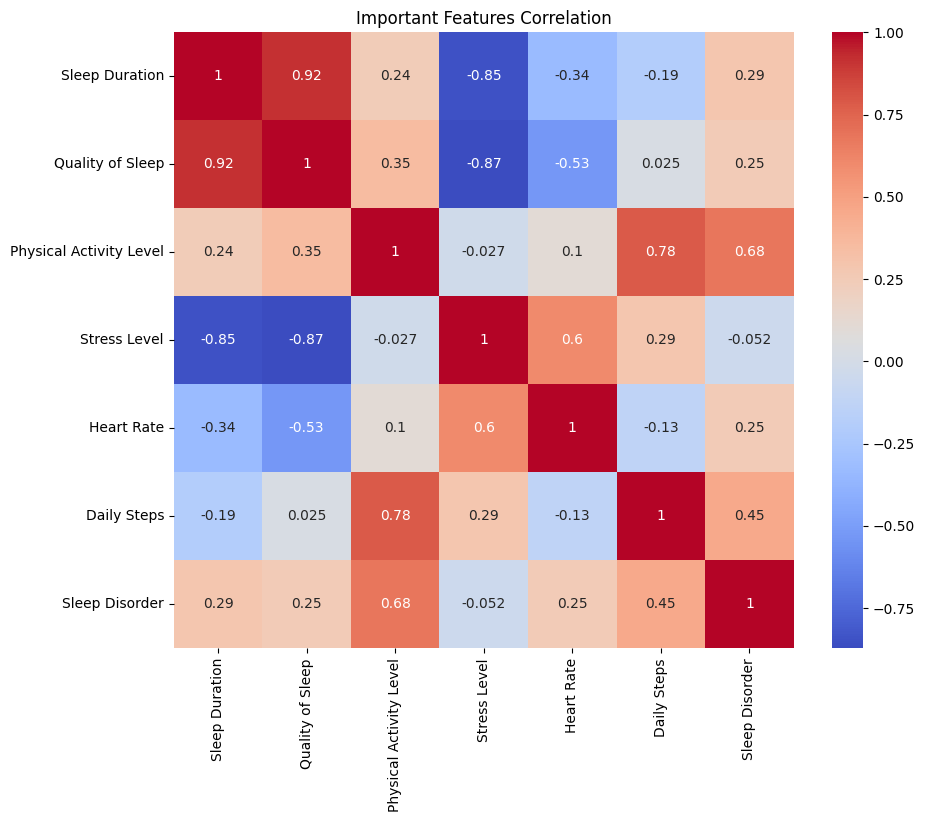

In [95]:
important_cols = [
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Sleep Disorder"
]

plt.figure(figsize=(10,8))

sns.heatmap(data[important_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Important Features Correlation")
plt.show()

In [96]:
data = data.drop("Blood Pressure", axis=1)

In [97]:
X = data.drop("Sleep Disorder", axis=1)
y = data["Sleep Disorder"]

In [98]:
X = pd.get_dummies(X, drop_first=True)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [101]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3145 - loss: 1.1240 - val_accuracy: 0.4839 - val_loss: 1.0409
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4032 - loss: 0.9956 - val_accuracy: 0.5484 - val_loss: 0.9725
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4435 - loss: 0.9541 - val_accuracy: 0.5484 - val_loss: 0.9113
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5161 - loss: 0.9170 - val_accuracy: 0.5806 - val_loss: 0.8544
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6290 - loss: 0.8661 - val_accuracy: 0.6452 - val_loss: 0.8026
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7097 - loss: 0.7718 - val_accuracy: 0.6452 - val_loss: 0.7561
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7581 - loss: 0.7449 - val_accuracy: 0.6774 - val_loss: 0.7140
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8468 - loss: 0.6842 - val_accuracy: 0.8710 - val_loss

In [103]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7742 - loss: 0.4254
Accuracy: 0.774193525314331


In [104]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[11  3]
 [ 4 13]]
              precision    recall  f1-score   support

         1.0       0.73      0.79      0.76        14
         2.0       0.81      0.76      0.79        17

    accuracy                           0.77        31
   macro avg       0.77      0.78      0.77        31
weighted avg       0.78      0.77      0.77        31



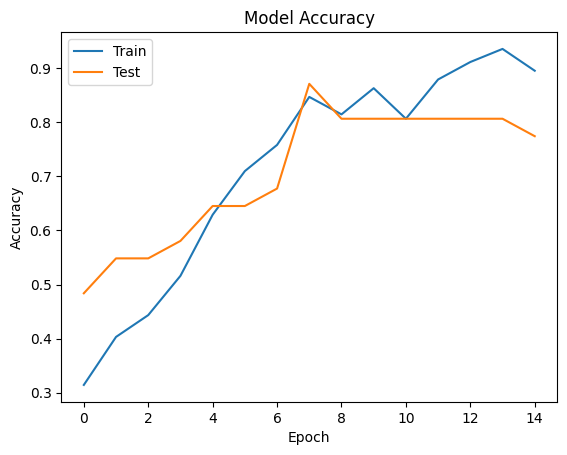

In [105]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'])

plt.show()